# Local activation analysis of EEG signals

*medusa-kernel 2.0*

**Local activation** metrics analyse each channel (or source)
**independently** to characterise localised brain activity. They are widely
used in cognitive neuroscience, clinical studies and BCI research.

This tutorial covers two families of metrics, all available under
`medusa.signal.metrics`:

- **Spectral** — derived from the Power Spectral Density (PSD):
    - band-specific power (absolute / relative),
    - median frequency.
- **Non-linear** — based on the complexity / irregularity of the signal:
    - sample entropy,
    - multiscale entropy,
    - Lempel-Ziv complexity.

You will learn how to:

- synthesise a resting-state EEG with `medusa.signal.generators`,
- preprocess it (filtering, re-referencing, epoching),
- extract spectral and non-linear features,
- visualise the results as scalp topographies and summary plots with
  `medusa.plots`.

All data here is **synthetic**, so the notebook runs anywhere with no
dataset download. To analyse a real recording instead, see the *Loading
legacy MEDUSA data* tutorial.

## Imports

<div class="alert alert-block alert-danger">
Important: execute the following cell <b>only</b> if you're using Google Colab!
</div>

In [1]:
!pip install medusa-kernel

Import the modules used in this notebook.

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import medusa_style
import medusa.plots as mp
from medusa.core.data import ChannelSet
from medusa.signal.generators import EEGSignalGenerator
from medusa.signal.frequency_filtering import FIRFilter
from medusa.signal.spatial_filtering import car
from medusa.signal.segmentation import segment_signal
from medusa.signal.transforms import power_spectral_density
from medusa.signal.metrics.spectral import band_power, median_frequency
from medusa.signal.metrics.nonlinear import (
    sample_entropy, multiscale_entropy, lempelziv_complexity)

medusa_style.apply()                       # opt in to the MEDUSA look
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
print('> All required packages were successfully imported')

> All required packages were successfully imported


## Synthesise a resting-state EEG

Instead of loading a recording, we synthesise a 90 s, 19-channel
resting-state EEG with `EEGSignalGenerator`, which models the signal as a
`1/f` background plus narrow-band oscillatory rhythms. We add a strong,
waxing-and-waning **posterior alpha rhythm** (the hallmark of eyes-closed
rest) so the spatial maps have a clear structure to recover.

`ChannelSet.add_unipolar_eeg_channels` mints a standard 10-20 montage from
the channel labels — the electrode positions the scalp plots need.

In [3]:
fs = 250.0          # sampling rate (Hz)
duration = 90.0     # recording length (s)
labels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
          'T7', 'C3', 'Cz', 'C4', 'T8',
          'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']
n_cha = len(labels)

# 1/f background + a mild widespread theta/alpha rhythm
eeg_gen = EEGSignalGenerator(
    fs=fs, oscillations=[(6.0, 5.0), (10.0, 4.0)],
    background_amplitude=15.0, modulation_freq=0.2, seed=42)
signal = eeg_gen.get_chunk(duration, n_cha)

# Enhance the alpha rhythm over posterior channels (eyes-closed occipital
# alpha), each with its own phase and slow waxing-and-waning envelope.
t = np.arange(signal.shape[0]) / fs
rng = np.random.default_rng(1)
for ch in ['P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']:
    i = labels.index(ch)
    env = 0.5 * (1 + np.sin(2 * np.pi * 0.1 * t + rng.uniform(0, 2 * np.pi)))
    signal[:, i] += 14.0 * env * np.sin(2 * np.pi * 10 * t + rng.uniform(0, 2 * np.pi))

channel_set = ChannelSet().add_unipolar_eeg_channels(labels)
print(f'> Signal shape (samples, channels): {signal.shape}')
print(f'> Sampling rate (Hz): {fs}')
print(f'> Channels: {channel_set.uids}')

> Signal shape (samples, channels): (22500, 19)
> Sampling rate (Hz): 250.0
> Channels: ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2']


## Preprocessing

A typical local-activation pipeline:

- **Band-pass** (1-70 Hz) to keep the neural range,
- **Notch** (49-51 Hz) to suppress power-line interference,
- **Common Average Reference** (CAR) with
  `medusa.signal.spatial_filtering.car`,
- **Epoching** into fixed-length 5 s segments with
  `medusa.signal.segmentation.segment_signal` (lengths are in *samples*).

Filters follow the scikit-learn `fit` / `transform` convention.

In [4]:
# Band-pass 1-70 Hz and notch 49-51 Hz (FIR, zero-phase)
bp = FIRFilter(order=1000, cutoff=(1, 70), btype='bandpass')
signal_prep = bp.fit_transform(signal, fs)
notch = FIRFilter(order=1001, cutoff=(49, 51), btype='bandstop')
signal_prep = notch.fit_transform(signal_prep, fs)

# Common average reference
signal_prep = car(signal_prep)

# 5 s non-overlapping epochs -> (n_epochs, n_samples, n_channels)
epochs = segment_signal(signal_prep, segment_length=int(5 * fs))
print(f'> Preprocessed. Epochs shape: {epochs.shape}')

> Preprocessed. Epochs shape: (18, 1250, 19)


## Spectral analysis

### Power Spectral Density

We estimate the PSD of every epoch with Welch's method
(`power_spectral_density`). `segment` and `overlap` are expressed as
**fractions** of the epoch length: here a 2.5 s Hamming window
(`segment=0.5` of the 5 s epoch) with 50% window overlap (`overlap=0.25`).

`plot_shaded_line` then summarises the per-epoch PSD as a mean ± 95% CI
band, contrasting a posterior channel (Oz-like **Pz**) with a frontal one
(**Fz**). The posterior alpha peak around 10 Hz stands out clearly.

> PSD shape (epochs, freqs, channels): (18, 313, 19)


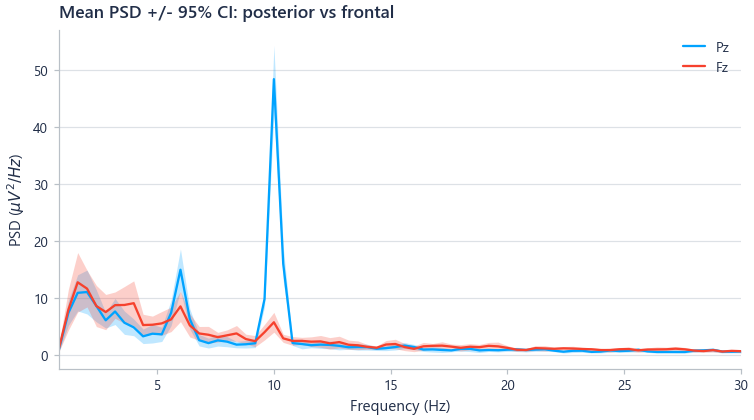

In [5]:
freqs, psd = power_spectral_density(
    epochs, fs, segment=0.5, overlap=0.25, window='hamming')
print(f'> PSD shape (epochs, freqs, channels): {psd.shape}')

band = (freqs >= 0.5) & (freqs <= 30)
fig, ax = plt.subplots(figsize=(8, 4))
for ch, color in [('Pz', medusa_style.categorical_color(0)),
                  ('Fz', medusa_style.categorical_color(1))]:
    idx = channel_set.uids.index(ch)
    mp.plot_shaded_line(psd[:, band, idx], ax, x=freqs[band], error='ci95',
                        color=color, label=ch)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'PSD ($\mu V^2/Hz$)')
ax.set_title('Mean PSD +/- 95% CI: posterior vs frontal')
plt.show()

### Band-power topographies

We compute the **relative** power of the canonical bands (delta, theta,
alpha, beta) per channel and epoch with `band_power`. Relative power
(`type='relative'`) expresses each band as a fraction of the total power in
`norm_range`, which is more comparable across channels than absolute power.

> Pass `band_power` the **raw** (non-normalised) PSD — it handles the
> normalisation internally.

The alpha map should light up over the posterior electrodes.

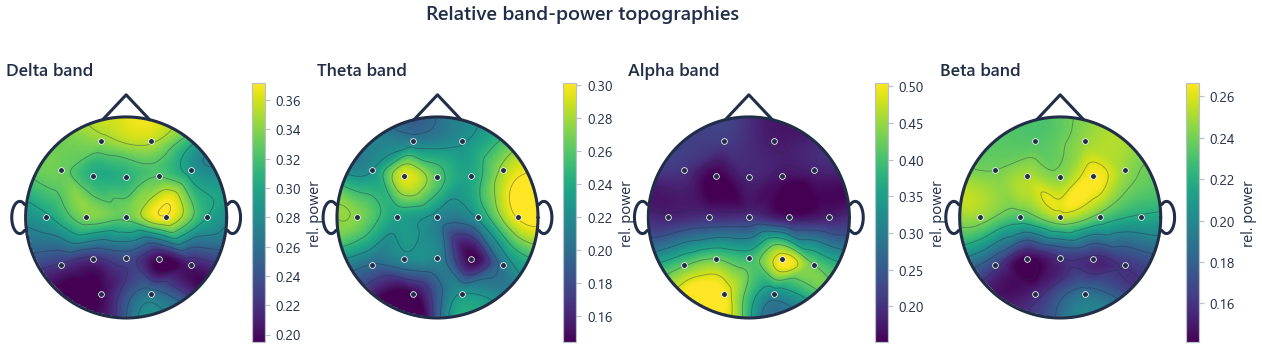

In [6]:
freq_bands = [(1, 4), (4, 8), (8, 13), (13, 30)]
band_names = ['Delta', 'Theta', 'Alpha', 'Beta']

powers = [band_power(psd, fs, target_band=b, type='relative',
                     norm_range=(1, 30)).mean(axis=0)   # mean over epochs
          for b in freq_bands]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, name, p in zip(axes, band_names, powers):
    mp.plot_topography(p, channel_set, ax, colorbar=True,
                       cbar_label='rel. power')
    ax.set_title(f'{name} band')
fig.suptitle('Relative band-power topographies', y=1.02)
mp.save_figure(fig, RESULTS / 'band_power_topographies.png')
plt.show()

### Median frequency

The **median frequency** is the frequency that splits the spectral power of
a band into two equal halves — a robust summary of where the power sits. We
map the alpha-band (8-13 Hz) median frequency across the scalp.

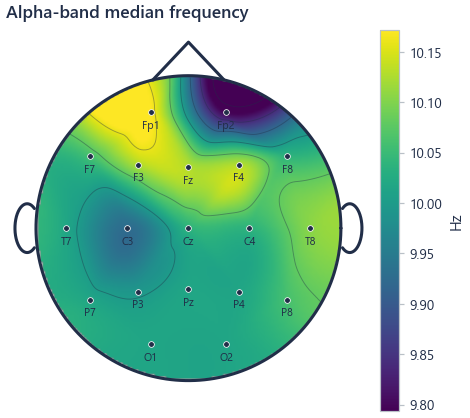

In [7]:
mf_alpha = median_frequency(psd, fs, target_band=(8, 13)).mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
mp.plot_topography(mf_alpha, channel_set, ax, show_labels=True,
                   colorbar=True, cbar_label='Hz')
ax.set_title('Alpha-band median frequency')
plt.show()

## Non-linear analysis

Non-linear metrics study the temporal structure of the signal — its
irregularity and complexity. They need longer windows than spectral
metrics, so we re-segment the preprocessed signal into 10 s epochs.

> These multi-channel measures are computed concurrently; very long signals
> can therefore be memory-intensive.

In [8]:
long_epochs = segment_signal(signal_prep, segment_length=int(10 * fs))
print(f'> Long epochs shape: {long_epochs.shape}')

> Long epochs shape: (9, 2500, 19)


### Sample entropy

**Sample entropy** (SampEn) quantifies the irregularity of a signal: higher
values mean less self-similar, more unpredictable dynamics.

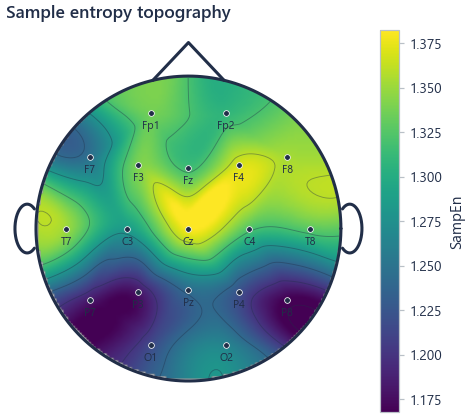

In [9]:
sampen = sample_entropy(long_epochs, m=1, r=0.25).mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
mp.plot_topography(sampen, channel_set, ax, show_labels=True,
                   colorbar=True, cbar_label='SampEn')
ax.set_title('Sample entropy topography')
mp.save_figure(fig, RESULTS / 'sample_entropy_topography.png')
plt.show()

### Multiscale entropy

**Multiscale entropy** (MSE) computes SampEn on coarse-grained versions of
the signal, revealing complexity across time scales. We compare a few
channels; the shaded band is the 95% CI across epochs.

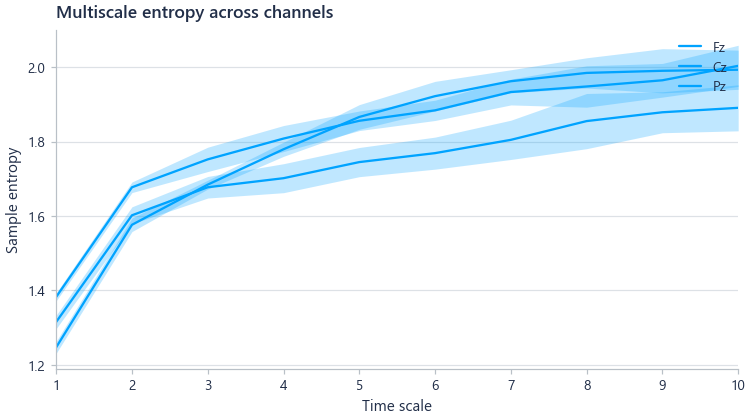

In [10]:
sel = ['Fz', 'Cz', 'Pz']
sel_idx = [channel_set.uids.index(c) for c in sel]
mse = multiscale_entropy(long_epochs[:, :, sel_idx], max_scale=10, m=1, r=0.25)
scales = np.arange(1, mse.shape[1] + 1)

fig, ax = plt.subplots(figsize=(8, 4))
for j, ch in enumerate(sel):
    mp.plot_shaded_line(mse[:, :, j], ax, x=scales, error='ci95', label=ch)
ax.set_xlabel('Time scale')
ax.set_ylabel('Sample entropy')
ax.set_title('Multiscale entropy across channels')
plt.show()

### Lempel-Ziv complexity

**Lempel-Ziv complexity** (LZC) measures the number of distinct patterns in
the (binarised) signal — a proxy for its randomness, related to Kolmogorov
complexity.

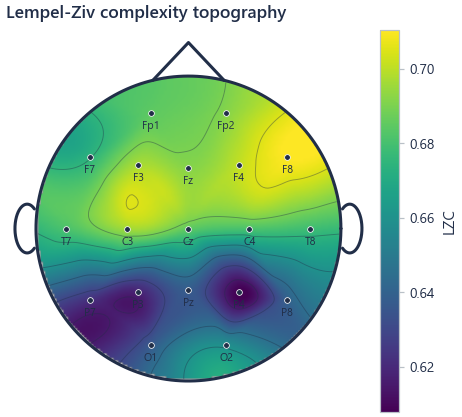

In [11]:
lzc = lempelziv_complexity(long_epochs).mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 4.5))
mp.plot_topography(lzc, channel_set, ax, show_labels=True,
                   colorbar=True, cbar_label='LZC')
ax.set_title('Lempel-Ziv complexity topography')
plt.show()

## Summary and next steps

In this tutorial you:

- synthesised a resting-state EEG with a posterior alpha rhythm using
  `medusa.signal.generators`,
- preprocessed it (filtering, CAR, epoching),
- extracted **spectral** features (band power, median frequency) and
  **non-linear** features (sample entropy, MSE, LZC),
- visualised channel-wise patterns as scalp topographies and summary plots
  with `medusa.plots`.

Ways to build on this:

- **Condition comparison** — apply the same metrics to different conditions
  and contrast them.
- **Feature aggregation** — stack per-channel features for machine learning
  (see the *Train a PyTorch classifier* tutorial).
- **Real data** — load a recording with the *Loading legacy MEDUSA data*
  tutorial and run the exact same pipeline.

See you in the next MEDUSA tutorial!

## References

1. Welch, P. D. (1967). *The use of Fast Fourier Transform for the
   estimation of power spectra.* IEEE Trans. Audio Electroacoust., 15(2),
   70-73.
2. Richman, J. S., & Moorman, J. R. (2000). *Physiological time-series
   analysis using approximate entropy and sample entropy.* Am. J. Physiol.
   Heart Circ. Physiol., 278(6), H2039-H2049.
3. Costa, M., Goldberger, A. L., & Peng, C.-K. (2002). *Multiscale entropy
   analysis of complex physiologic time series.* Phys. Rev. Lett., 89(6),
   068102.
4. Lempel, A., & Ziv, J. (1976). *On the complexity of finite sequences.*
   IEEE Trans. Inf. Theory, 22(1), 75-81.